SOLO - S-ADCP transect

DOPPIOE - Numerical

LATTE - drifter, drifter and sattellite (multimodel) 

Keep it simple, be like water, flow

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q


In [3]:
def latte(xi, yi, ui, vi):
    from scipy.optimize import least_squares
    xi, yi, ui, vi = map(lambda a: np.asarray(a, float), (xi, yi, ui, vi))
    m = np.isfinite(xi) & np.isfinite(yi) & np.isfinite(ui) & np.isfinite(vi)
    x, y, u_i, v_i = xi[m], yi[m], ui[m], vi[m]
    n = x.size
    if n < 3:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan, np.nan

    p0 = np.array([x.mean(), y.mean(), 1., 0., 1.])  # xc,yc,Aq11,Aq12,Aq22

    def fun(p):
        xc,yc,a11,a12,a22 = p
        dx, dy = x-xc, y-yc
        u = -2*a22*dy - 2*a12*dx
        v =  2*a11*dx + 2*a12*dy
        r = np.empty(2*n); r[:n]=u-u_i; r[n:]=v-v_i
        return r

    def jac(p):
        xc,yc,a11,a12,a22 = p
        dx, dy = x-xc, y-yc
        J = np.zeros((2*n,5))
        # u = -2*Aq22*(y-yc) - 2*Aq12*(x-xc)
        J[:n,0], J[:n,1], J[:n,3], J[:n,4] = 2*a12, 2*a22, -2*dx, -2*dy
        # v = 2*Aq11*(x-xc) + 2*Aq12*(y-yc)
        J[n:,0], J[n:,1], J[n:,2], J[n:,3] = -2*a11, -2*a12, 2*dx, 2*dy
        return J

    xc,yc,a11,a12,a22 = least_squares(fun, p0, jac=jac).x

    dx, dy = x-xc, y-yc
    u = -2*a22*dy - 2*a12*dx
    v =  2*a11*dx + 2*a12*dy
    err2 = ((u-u_i)**2 + (v-v_i)**2).sum()
    tot2 = ((u_i-u_i.mean())**2 + (v_i-v_i.mean())**2).sum()
    r2 = 1 - err2/tot2 if tot2 > 0 else np.nan

    w = 2*(a11+a22)
    AQ = np.array([[a11,a12],[a12,a22]])
    det = AQ[0,0]*AQ[1,1] - AQ[0,1]*AQ[1,0]
    A = np.sign(a11)*np.sqrt(abs(det))
    Q = AQ/A if A != 0 else np.full((2,2), np.nan)

    return xc, yc, w, Q, A, r2
    

### Drifter Data

In [4]:
drifter_path = '/srv/scratch/z5297792/ESP_Paper_Data/drifter_data_CCE_2023_6h.nc'

drifter_dataset = nc.Dataset(drifter_path, mode='r')

u_drif, v_drif = drifter_dataset['ve'][:].data, drifter_dataset['vn'][:].data
lon_drif, lat_drif = drifter_dataset['longitude'][:].data, drifter_dataset['latitude'][:].data
ID_drif =  drifter_dataset['ID'][:]
secs = drifter_dataset['time'][:].data
tim_drif = [datetime.utcfromtimestamp(t).strftime('%Y-%m-%d %H:%M:%S') for t in secs]
df_drifters = pd.DataFrame({'ID': ID_drif.astype(int), 'Lon': lon_drif, 'Lat': lat_drif, 'u': u_drif, 'v': v_drif, 'Time': tim_drif})
df_drifters['Time'] = pd.to_datetime(df_drifters['Time'])
df_drifters = df_drifters[np.hypot(df_drifters.u, df_drifters.v) < 100]
df_drifters = df_drifters.reset_index().drop(columns=['index'])
df_drifters = df_drifters[df_drifters.Time < pd.Timestamp('2024-02-10 00:00:00')]

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
df_drifters['x'] = (df_drifters.Lon - theta_mean) * 111000 * np.cos(np.deg2rad(phi_mean))
df_drifters['y'] = (df_drifters.Lat - phi_mean) * 111000

df_drifters.head()


,ID,Lon,Lat,u,v,Time,x,y
0,300534062034380,153.975,-37.651,0.39605,0.45606,2023-10-19 12:00:00,-28466.208360,27639.0
1,300534062034380,154.095,-37.579,0.47131,0.32648,2023-10-19 18:00:00,-17955.608350,35631.0
2,300534062034380,154.206,-37.523,0.47029,0.15047,2023-10-20 00:00:00,-8233.303341,41847.0
3,300534062034380,154.325,-37.520,0.49572,-0.06028,2023-10-20 06:00:00,2189.708335,42180.0
4,300534062034380,154.448,-37.547,0.45842,-0.19557,2023-10-20 12:00:00,12963.073346,39183.0


In [5]:
start = df_drifters.Time.min() + pd.Timedelta(days=1)
end   = df_drifters.Time.max() - pd.Timedelta(days=1)
times = pd.date_range(start, end, freq='D')

results = []
dic_drif = {}
for t in times:
    mask = df_drifters.Time.between(t - pd.Timedelta(days=1),
                                     t + pd.Timedelta(days=1))
    
    xi, yi = df_drifters.loc[mask, ['x', 'y']].values.T
    ui, vi = df_drifters.loc[mask, ['u', 'v']].values.T
    dic_drif[t] = pd.DataFrame({'xi': xi, 'yi': yi, 'ui': ui, 'vi': vi, 'ID':df_drifters.loc[mask, 'ID']})

    xc, yc, w, Q, A, r2 = latte(xi, yi, ui, vi) 
        
    results.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, r2=r2, Time=t))

df_res = pd.DataFrame(results)
alpha = []
for k in range(len(df_res)):
    alpha.append(axis_ratio_from_Q(df_res.iloc[k].Q))
df_res['alpha'] = alpha
df_res


,xc,yc,w,Q,A,r2,Time,alpha
0,-3294.287927,-5573.143352,-0.000027,"[[1.263598260460861, -0.10707400872613092], [-...",-0.000007,0.991515,2023-10-20 12:00:00,1.287155
1,1945.671980,-1983.946961,-0.000031,"[[1.329320808603612, -0.045006095106227315], [...",-0.000007,0.980386,2023-10-21 12:00:00,1.332819
2,-5712.588428,-4674.576006,-0.000031,"[[1.0579383857758031, 0.05131669545893002], [0...",-0.000008,0.959225,2023-10-22 12:00:00,1.078132
3,-11550.619818,-7158.844551,-0.000033,"[[1.027174531531638, 0.125849825274393], [0.12...",-0.000008,0.928635,2023-10-23 12:00:00,1.135361
4,-12920.830789,-1271.000510,-0.000032,"[[1.0737560405562327, -0.051220084976039734], ...",-0.000008,0.916079,2023-10-24 12:00:00,1.090494
...,...,...,...,...,...,...,...,...
107,-316915.391322,79699.292141,-0.000036,"[[1.1809806981325994, -0.24468992803827475], [...",-0.000009,0.974400,2024-02-04 12:00:00,1.322006
108,-318831.676910,73550.482819,-0.000039,"[[0.9598894244962433, -0.2878569758973735], [-...",-0.000009,0.949578,2024-02-05 12:00:00,1.343894
109,-314499.721779,64718.385922,-0.000034,"[[0.7170437098276522, 0.19032273340433548], [0...",-0.000008,0.874984,2024-02-06 12:00:00,1.491881
110,-316009.011653,66870.755713,-0.000042,"[[0.6369083577037351, 0.26636756725649563], [0...",-0.000009,0.854350,2024-02-07 12:00:00,1.745487


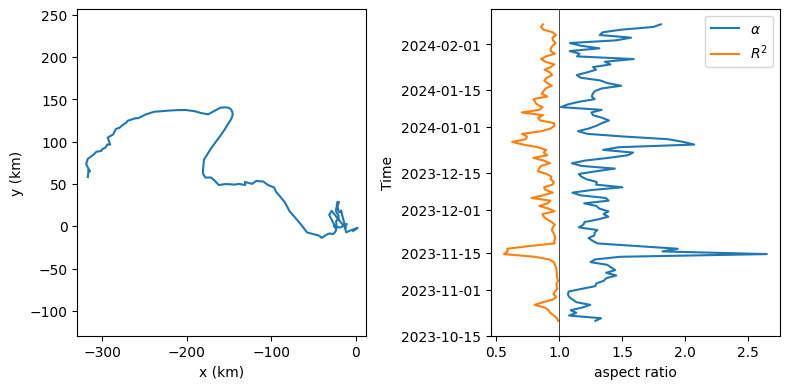

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=False)
axs[0].plot(df_res.xc/1e3, df_res.yc/1e3); axs[0].axis('equal')
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')
axs[1].plot(df_res.alpha, df_res.Time, label=r'$\alpha$')
axs[1].set_xlabel('aspect ratio'); axs[1].set_ylabel('Time')
axs[1].plot(df_res.r2, df_res.Time, label=r'$R^2$')
axs[1].legend(); axs[1].axvline(1, lw=.5, color='k')
plt.tight_layout()


### Satellite Data

In [49]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)
ds_sat


<xarray.Dataset> Size: 4MB
Dimensions:  (time: 116, lat: 41, lon: 46)
Coordinates:
  * lat      (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon      (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x        (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y        (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time     (time) datetime64[ns] 928B 2023-10-19T06:00:00 ... 2024-02-11T06...
Data variables:
    u        (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.1642 0.2129
    v        (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.2817 -0.2019

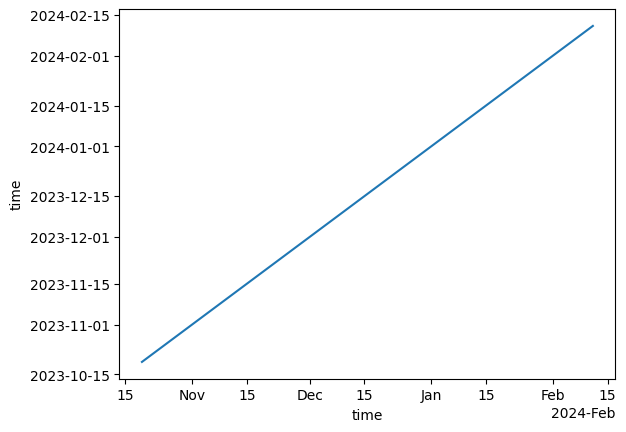

In [50]:
ds_sat.time.plot()

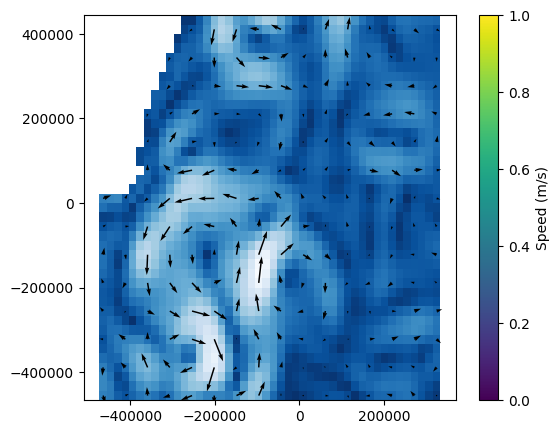

In [60]:
t = '2024-01-21T06:00:00'

u = ds_sat.u.sel(time=t)
v = ds_sat.v.sel(time=t)
speed = np.sqrt(u**2 + v**2)

plt.figure(figsize=(6,5))
plt.pcolormesh(ds_sat.x, ds_sat.y, speed, shading='auto', cmap='Blues_r')

spac = 3
plt.quiver(
    ds_sat.x.values[::spac, ::spac],
    ds_sat.y.values[::spac, ::spac],
    u.values[::spac, ::spac],
    v.values[::spac, ::spac],
    scale=15
)

plt.colorbar(label='Speed (m/s)')
plt.axis('equal')
plt.show()
